<a href="https://colab.research.google.com/github/pavanichowdary19/MLOOPS/blob/main/Mlops_lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
!pip install mlflow -q

In [26]:
import mlflow
import mlflow.sklearn

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [27]:
df = pd.read_csv("titanic.csv")

X = df[
    [
        "Pclass",
        "Sex",
        "Age",
        "SibSp",
        "Parch",
        "Fare",
        "Embarked"
    ]
]

y = df["Survived"]

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [29]:
numerical_features = [
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

categorical_features = [
    "Pclass",
    "Sex",
    "Embarked"
]

In [30]:
numerical_pipeline = Pipeline(
    steps=[
        ("missing_values", SimpleImputer(strategy="median")),
        ("scaling", StandardScaler())
    ]
)

In [31]:
categorical_pipeline = Pipeline(
    steps=[
        ("missing_values", SimpleImputer(strategy="most_frequent")),
        ("encoding", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [32]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [33]:
mlflow.set_experiment(
    "Titanic Survival Prediction"
)

<Experiment: artifact_location='/content/mlruns/1', creation_time=1787550933888, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1787550933888, lifecycle_stage='active', name='Titanic Survival Prediction', tags={}, trace_location=None, workspace='default'>

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

import mlflow
import mlflow.sklearn

In [35]:
with mlflow.start_run(run_name="Logistic Regression"):

    model_pipeline = Pipeline(
        steps=[
            ("preprocessing", preprocessor),
            (
                "model",
                LogisticRegression(
                    C=1.0,
                    max_iter=1000
                )
            )
        ]
    )

    model_pipeline.fit(X_train, y_train)

    predictions = model_pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("C", 1.0)

    mlflow.log_metric("accuracy", accuracy)

    mlflow.sklearn.log_model(
        sk_model=model_pipeline,
        name="model",
        serialization_format="cloudpickle"
    )

    print("Logistic Regression Accuracy:", accuracy)

2026/08/24 06:04:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logistic Regression Accuracy: 0.8044692737430168


In [36]:
with mlflow.start_run(run_name="Decision Tree"):

    model_pipeline = Pipeline(
        steps=[
            ("preprocessing", preprocessor),
            (
                "model",
                DecisionTreeClassifier(
                    max_depth=5,
                    random_state=42
                )
            )
        ]
    )

    model_pipeline.fit(X_train, y_train)

    predictions = model_pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    mlflow.log_param("model", "DecisionTree")
    mlflow.log_param("max_depth", 5)

    mlflow.log_metric("accuracy", accuracy)

    mlflow.sklearn.log_model(
        sk_model=model_pipeline,
        name="model",
        serialization_format="cloudpickle"
    )

    print("Decision Tree Accuracy:", accuracy)

2026/08/24 06:04:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Decision Tree Accuracy: 0.7597765363128491


In [37]:
with mlflow.start_run(run_name="Random Forest"):

    model_pipeline = Pipeline(
        steps=[
            ("preprocessing", preprocessor),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=100,
                    max_depth=5,
                    random_state=42
                )
            )
        ]
    )

    model_pipeline.fit(X_train, y_train)

    predictions = model_pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    mlflow.log_param("model", "RandomForest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 5)

    mlflow.log_metric("accuracy", accuracy)

    mlflow.sklearn.log_model(
        sk_model=model_pipeline,
        name="model",
        serialization_format="cloudpickle"
    )

    print("Random Forest Accuracy:", accuracy)

2026/08/24 06:05:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest Accuracy: 0.8100558659217877


In [ ]:
models = {
    "LogisticRegression": LogisticRegression(
        C=1.0,
        max_iter=1000
    ),

    "DecisionTree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42
    )
}

In [39]:
for model_name, model in models.items():

    with mlflow.start_run(run_name=model_name):

        pipeline = Pipeline(
            steps=[
                ("preprocessing", preprocessor),
                ("model", model)
            ]
        )

        pipeline.fit(X_train, y_train)

        predictions = pipeline.predict(X_test)

        accuracy = accuracy_score(
            y_test,
            predictions
        )

        mlflow.log_param(
            "model",
            model_name
        )

        mlflow.log_metric(
            "accuracy",
            accuracy
        )

        mlflow.sklearn.log_model(
            sk_model=pipeline,
            name="model",
            serialization_format="cloudpickle"
        )

        print(
            model_name,
            "Accuracy:",
            accuracy
        )

2026/08/24 06:05:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/24 06:05:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LogisticRegression Accuracy: 0.8044692737430168
DecisionTree Accuracy: 0.7597765363128491


2026/08/24 06:05:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RandomForest Accuracy: 0.8100558659217877


In [ ]:
import mlflow

mlflow.set_tracking_uri("sqlite:////content/mlflow.db")

mlflow.set_experiment(
    "Titanic Survival Prediction"
)

print("Tracking URI:", mlflow.get_tracking_uri())

Tracking URI: sqlite:////content/mlflow.db


In [ ]:
experiment = mlflow.get_experiment_by_name(
    "Titanic Survival Prediction"
)

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id]
)

comparison = runs[
    [
        "tags.mlflow.runName",
        "params.model",
        "metrics.accuracy"
    ]
].sort_values(
    "metrics.accuracy",
    ascending=False
)

comparison

,tags.mlflow.runName,params.model,metrics.accuracy
0,RandomForest,RandomForest,0.810056
3,Random Forest,RandomForest,0.810056
5,Logistic Regression,LogisticRegression,0.804469
2,LogisticRegression,LogisticRegression,0.804469
1,DecisionTree,DecisionTree,0.759777
4,Decision Tree,DecisionTree,0.759777


In [ ]:
for model_name, model in models.items():

    with mlflow.start_run(run_name=model_name):

        pipeline = Pipeline(
            steps=[
                ("preprocessing", preprocessor),
                ("model", model)
            ]
        )

        pipeline.fit(X_train, y_train)

        predictions = pipeline.predict(X_test)

        accuracy = accuracy_score(y_test, predictions)

        # Model name
        mlflow.log_param("model", model_name)

        # Log all model parameters
        mlflow.log_params(model.get_params())

        # Metric
        mlflow.log_metric("accuracy", accuracy)

        mlflow.sklearn.log_model(
            sk_model=pipeline,
            name="model",
            serialization_format="cloudpickle"
        )

        print(model_name, "Accuracy:", accuracy)

2026/08/24 05:59:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/24 05:59:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LogisticRegression Accuracy: 0.8044692737430168
DecisionTree Accuracy: 0.7597765363128491


2026/08/24 05:59:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RandomForest Accuracy: 0.8100558659217877


In [ ]:
experiment = mlflow.get_experiment_by_name(
    "Titanic Survival Prediction"
)

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id]
)

runs

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.accuracy,params.min_impurity_decrease,params.max_depth,params.bootstrap,...,params.dual,params.intercept_scaling,params.C,params.multi_class,params.max_iter,params.solver,tags.mlflow.user,tags.mlflow.runName,tags.mlflow.source.name,tags.mlflow.source.type
0,052ee5a82baf46caaf432037397ba1d8,1,FINISHED,/content/mlruns/1/052ee5a82baf46caaf432037397b...,2026-08-24 05:59:18.468000+00:00,2026-08-24 05:59:23.138000+00:00,0.810056,0.0,5,True,...,None,None,None,None,None,None,root,RandomForest,fileId=1RMSe0uPtrWaZ-4b0SearbVDnScriQiWB,NOTEBOOK
1,bd096f8787124930bf1603b31243b164,1,FINISHED,/content/mlruns/1/bd096f8787124930bf1603b31243...,2026-08-24 05:59:13.121000+00:00,2026-08-24 05:59:18.449000+00:00,0.759777,0.0,5,None,...,None,None,None,None,None,None,root,DecisionTree,fileId=1RMSe0uPtrWaZ-4b0SearbVDnScriQiWB,NOTEBOOK
2,72d8edbba8504684ba277b8ab4d4dd14,1,FINISHED,/content/mlruns/1/72d8edbba8504684ba277b8ab4d4...,2026-08-24 05:59:04.101000+00:00,2026-08-24 05:59:13.107000+00:00,0.804469,None,None,None,...,False,1,1.0,deprecated,1000,lbfgs,root,LogisticRegression,fileId=1RMSe0uPtrWaZ-4b0SearbVDnScriQiWB,NOTEBOOK
3,cd00cffb0dab4c42beaff947b8861f7b,1,FINISHED,/content/mlruns/1/cd00cffb0dab4c42beaff947b886...,2026-08-24 05:57:54.620000+00:00,2026-08-24 05:58:02.288000+00:00,0.810056,None,None,None,...,None,None,None,None,None,None,root,RandomForest,fileId=1RMSe0uPtrWaZ-4b0SearbVDnScriQiWB,NOTEBOOK
4,466385aaa19348129e24335da4c2b5ef,1,FINISHED,/content/mlruns/1/466385aaa19348129e24335da4c2...,2026-08-24 05:57:49.094000+00:00,2026-08-24 05:57:54.607000+00:00,0.759777,None,None,None,...,None,None,None,None,None,None,root,DecisionTree,fileId=1RMSe0uPtrWaZ-4b0SearbVDnScriQiWB,NOTEBOOK
5,d06082ecb6bb4eedbdb04bc99848070c,1,FINISHED,/content/mlruns/1/d06082ecb6bb4eedbdb04bc99848...,2026-08-24 05:57:42.715000+00:00,2026-08-24 05:57:49.081000+00:00,0.804469,None,None,None,...,None,None,None,None,None,None,root,LogisticRegression,fileId=1RMSe0uPtrWaZ-4b0SearbVDnScriQiWB,NOTEBOOK
6,9af4b3fe96f3474aa4e265e11ff7c703,1,FINISHED,/content/mlruns/1/9af4b3fe96f3474aa4e265e11ff7...,2026-08-24 05:57:04.482000+00:00,2026-08-24 05:57:12.930000+00:00,0.810056,None,5,None,...,None,None,None,None,None,None,root,Random Forest,fileId=1RMSe0uPtrWaZ-4b0SearbVDnScriQiWB,NOTEBOOK
7,978d035cb1f542b8bba47484604cbeed,1,FINISHED,/content/mlruns/1/978d035cb1f542b8bba47484604c...,2026-08-24 05:56:29.544000+00:00,2026-08-24 05:56:43.176000+00:00,0.759777,None,5,None,...,None,None,None,None,None,None,root,Decision Tree,fileId=1RMSe0uPtrWaZ-4b0SearbVDnScriQiWB,NOTEBOOK
8,d9f6effc42024901ab4536275647338e,1,FINISHED,/content/mlruns/1/d9f6effc42024901ab4536275647...,2026-08-24 05:56:06.507000+00:00,2026-08-24 05:56:19.859000+00:00,0.804469,None,None,None,...,None,None,1.0,None,None,None,root,Logistic Regression,fileId=1RMSe0uPtrWaZ-4b0SearbVDnScriQiWB,NOTEBOOK


In [ ]:
comparison = runs[
    [
        "tags.mlflow.runName",
        "params.model",
        "params.C",
        "params.max_depth",
        "params.n_estimators",
        "metrics.accuracy"
    ]
].sort_values(
    "metrics.accuracy",
    ascending=False
)

comparison

,tags.mlflow.runName,params.model,params.C,params.max_depth,params.n_estimators,metrics.accuracy
0,RandomForest,RandomForest,None,5,100,0.810056
3,RandomForest,RandomForest,None,None,None,0.810056
6,Random Forest,RandomForest,None,5,100,0.810056
5,LogisticRegression,LogisticRegression,None,None,None,0.804469
2,LogisticRegression,LogisticRegression,1.0,None,None,0.804469
8,Logistic Regression,LogisticRegression,1.0,None,None,0.804469
1,DecisionTree,DecisionTree,None,5,None,0.759777
4,DecisionTree,DecisionTree,None,None,None,0.759777
7,Decision Tree,DecisionTree,None,5,None,0.759777


In [ ]:
import pandas as pd

comparison = runs[
    [
        "tags.mlflow.runName",
        "params.model",
        "params.C",
        "params.max_depth",
        "params.n_estimators",
        "metrics.accuracy"
    ]
].copy()

comparison.columns = [
    "Run Name",
    "Model",
    "C",
    "Max Depth",
    "No. of Trees",
    "Accuracy"
]

comparison = comparison.dropna(
    subset=["Model", "Accuracy"]
)

comparison["Accuracy"] = (
    comparison["Accuracy"] * 100
).round(2)

comparison = comparison.sort_values(
    "Accuracy",
    ascending=False
)

comparison

,Run Name,Model,C,Max Depth,No. of Trees,Accuracy
0,RandomForest,RandomForest,None,5,100,81.01
3,RandomForest,RandomForest,None,None,None,81.01
6,Random Forest,RandomForest,None,5,100,81.01
5,LogisticRegression,LogisticRegression,None,None,None,80.45
2,LogisticRegression,LogisticRegression,1.0,None,None,80.45
8,Logistic Regression,LogisticRegression,1.0,None,None,80.45
1,DecisionTree,DecisionTree,None,5,None,75.98
4,DecisionTree,DecisionTree,None,None,None,75.98
7,Decision Tree,DecisionTree,None,5,None,75.98


In [ ]:
best_models = (
    comparison
    .sort_values("Accuracy", ascending=False)
    .drop_duplicates(subset=["Model"])
    .reset_index(drop=True)
)

best_models

,Run Name,Model,C,Max Depth,No. of Trees,Accuracy
0,RandomForest,RandomForest,None,5,100,81.01
1,LogisticRegression,LogisticRegression,None,None,None,80.45
2,DecisionTree,DecisionTree,None,5,None,75.98


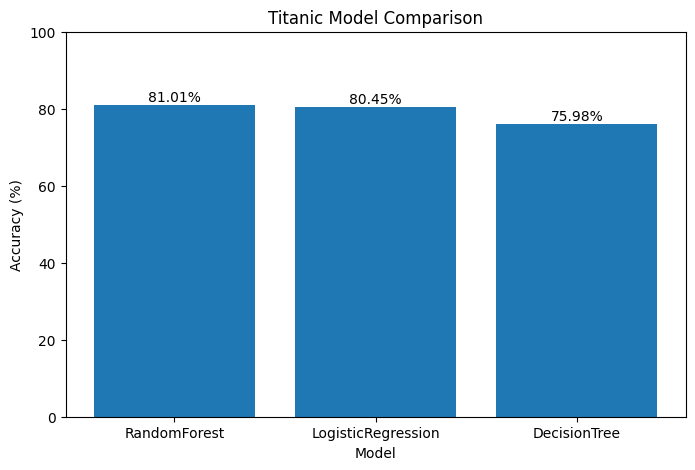

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    best_models["Model"],
    best_models["Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("Titanic Model Comparison")

plt.ylim(0, 100)

for i, value in enumerate(best_models["Accuracy"]):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

In [48]:
display(
    best_models[
        [
            "Model",
            "C",
            "Max Depth",
            "No. of Trees",
            "Accuracy"
        ]
    ].style
    .format({"Accuracy": "{:.2f}%"})
    .highlight_max(
        subset=["Accuracy"],
        axis=0
    )
)

,Model,C,Max Depth,No. of Trees,Accuracy
0,RandomForest,None,5,100,81.01%
1,LogisticRegression,1.0,None,None,80.45%
2,DecisionTree,None,5,None,75.98%
